# 09 - From the Experiment to the Forecast

Eight notebooks trained models, measured them, and threw them away. This one
trains the model that stays, saves it to a file, and uses that file to
forecast the six weeks the competition asks for and any new row that comes
later.

Before the code, this notebook explains the road that led here, because the
order of the steps is the method. Someone who reads only this notebook should
understand what a forecasting project is made of, and why every step was
done when it was done.

## How a forecasting project is built

Every step below answers one question, and each answer decides what the next
step is. The right column says where the step lives in this repository.

| Step | The question it answers | Why it comes here | Where |
|---|---|---|---|
| 1. The problem | What do we predict, how far ahead, and what may we use? | Six weeks ahead rules out everything we only learn on the day, such as the number of customers. | README, notebook 01 |
| 2. The data | Is the data clean, and what does it look like? | A model built on a broken table learns the breaks. | Notebook 01 |
| 3. The metric | How do we count an error? | RMSPE reads errors as percentages and squares them, so a few bad days can carry a large part of the total. Every later decision follows from that. | Notebook 02 |
| 4. The validation | How do we measure without cheating? | Four windows in time, in the shape of the real task. See the next section. | Notebook 02 |
| 5. The baseline | What does a simple rule score? | Without a baseline, 0.15 is only a number. With it, 0.15 is "ten percent better than the median". | Notebook 02 |
| 6. The model | What does gradient boosting add, and how should it learn? | The logarithm of the sales, because the metric is a percentage. | Notebook 03 |
| 7. The structure | Should all stores share one model? | Four behaviour groups, one model each, beat one model for all. | Notebook 04 |
| 8. The error analysis | Where does the model fail? | The error sat in a few days, not in the stores. This decided what was built next. | Notebook 05 |
| 9. The features | Can we give the model what it could not see? | The closed days around each date: the largest gain of the project. | Notebooks 06, 07 |
| 10. The tuning | Are the settings right? | Last, so that it works on the final features. It changed nothing. | Notebook 08 |
| 11. The final fit | Train once, on every day we have, and save. | This notebook. | Notebook 09 |
| 12. The forecast | Score the days we do not know, and the rows that come later. | This notebook. | Notebook 09 |
| 13. After the forecast | Watch the error when the real sales arrive, and retrain. | The scoring half is here, as the `evaluate` command; the loop that runs it every week is not, and the last section says what it would be. | Notebook 09, `src/forecaster.py` |

Steps 10 and 11 are the ones people often do first. Tuning early makes every
later experiment slower and tunes a model that the next feature replaces.
Fitting the final model early gives a model without the error analysis, which
is where most of the gain came from.

## Backtesting, and the four jobs of a hidden window

A **backtest** pretends that a day in the past is today. Everything before
that day is the training data, the six weeks after it are hidden, the model
predicts them, and the prediction is compared with the real sales. Then the
same is done at three other days. Our four windows end on 27 March, 8 May,
19 June and 31 July 2015, and each one trains on every day before it starts.

A random split would not do. It would put Tuesday in the training set and
Monday of the same week in the test set, and the model would learn from the
future of the days it predicts. The score would look wonderful and mean
nothing.

A hidden window does four jobs, and it is worth naming them, because they
are not the same job.

1. **An honest number.** The error on days the model has never seen is the
   error to expect in real use. Ours is 0.1189, the mean of four windows and
   three seeds. Done in notebooks 02 to 08.
2. **A fair choice between recipes.** Logarithm or not, one model or four,
   keep a feature or drop it: every decision was made by comparing scores on
   the same hidden windows. Done in notebooks 03 to 08.
3. **Over- and under-fitting.** A model that scores far better on the days it
   trained on than on hidden days has memorised; one that scores badly on
   both has not learned enough. This needs the training error next to the
   hidden error, and no notebook so far printed the two side by side. **This
   notebook does, as check 2.**
4. **Leakage.** If the hidden score is too good to be true, the model sees
   the future somewhere. The `Customers` column was dropped in notebook 01
   for exactly this reason, but nobody showed what it would have done. **This
   notebook does, as check 3.**

Check 1 comes first and is about the code, not the model: the saved file
must give the same number as the notebooks did.

In [1]:
import sys
import time
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from src.data_loader import DataLoader
from src.forecaster import Forecaster, evaluate
from src.model import SalesModel
from src.metrics import rmspe

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
pl.Config.set_tbl_rows(20)

loader = DataLoader(PROJECT_ROOT / "data")
df = loader.load()                              # open days, with sales
calendar = loader.load(drop_closed=False)       # every day, closed ones too
MODELS = PROJECT_ROOT / "models"
print("Open days:", f"{df.height:,}", "  from", df["Date"].min(), "to", df["Date"].max())

Open days: 844,392   from 2013-01-01 to 2015-07-31


## Check 1: the saved file gives the number of the notebooks

The last window of the backtest hides 20 June to 31 July 2015. Notebook 06
scored it at 0.1102, the mean of three seeds. Here the `Forecaster` is
trained on the days before the window, written to disk, read back, and asked
to predict the hidden weeks - the same road that a new row will travel later.
With one seed the number should land within a few thousandths of 0.1102.

The `Forecaster` holds every part that learned something: the store
statistics, the store groups, the four models and their tree counts. It also
holds the calendar of opening days, which is not learned but is needed to
build the closed-day columns for the days it predicts.

In [2]:
CUT = date(2015, 6, 19)
before = df.filter(pl.col("Date") <= CUT)
before_calendar = calendar.filter(pl.col("Date") <= CUT)
hidden = calendar.filter(pl.col("Date") > CUT)   # the six weeks, closed days too

started = time.perf_counter()
Forecaster().fit(before, before_calendar).save(MODELS / "check.pkl")
print(f"Trained and saved in {time.perf_counter() - started:.0f} seconds")

check = Forecaster.load(MODELS / "check.pkl")
scored = check.predict(hidden)
open_rows = scored.filter(pl.col("Open") == 1)
check_hidden = rmspe(open_rows["Sales"], open_rows["prediction"])
print(f"Hidden window, from the saved file: {check_hidden:.4f}   (notebook 06: 0.1102)")
print(f"Closed days predicted as zero: {(scored.filter(pl.col('Open') == 0)['prediction'] == 0).all()}")

# The same number, from the command that will score real sales later.
print()
print(evaluate(scored))

Trained and saved in 75 seconds


Hidden window, from the saved file: 0.1083   (notebook 06: 0.1102)
Closed days predicted as zero: True

shape: (8, 3)
┌────────────┬───────┬────────┐
│ week       ┆ rows  ┆ rmspe  │
│ ---        ┆ ---   ┆ ---    │
│ str        ┆ i64   ┆ f64    │
╞════════════╪═══════╪════════╡
│ all        ┆ 40282 ┆ 0.1083 │
│ 2015-06-15 ┆ 1146  ┆ 0.0936 │
│ 2015-06-22 ┆ 6718  ┆ 0.0967 │
│ 2015-06-29 ┆ 6720  ┆ 0.1225 │
│ 2015-07-06 ┆ 6715  ┆ 0.1098 │
│ 2015-07-13 ┆ 6708  ┆ 0.0965 │
│ 2015-07-20 ┆ 6710  ┆ 0.1122 │
│ 2015-07-27 ┆ 5565  ┆ 0.1133 │
└────────────┴───────┴────────┘


**0.1083 against 0.1102.** The saved file, read back from disk, scores the
hidden window two thousandths better than the three-seed mean of notebook 06,
which is inside the spread of a single seed. The road a new row will travel -
load the file, extend the calendar, build the features, find the group, ask
its model - gives the number the experiments gave. The check took a little
over a minute, most of it training.

The table under it comes from `evaluate`, the command that will score a
forecast when the real sales arrive: the whole period first, then week by
week. Here it scores the hidden window, and the weeks say something the
single number hides - the error is not the same every week, and a bad week
would show up on its own.

## Check 2: over- and under-fitting

The same model, now scored on the days it trained on. Three numbers side by
side say which of the three things happened:

- **Memorised** (over-fitting): the training error is far below the hidden
  error. The model learned the noise of its own rows.
- **Not learned enough** (under-fitting): both errors are high, close to the
  baseline. The model is too simple for the data.
- **Learned**: the training error is lower than the hidden error, as it must
  be, but not by much, and both are far below the baseline.

The main guard against memorising in gradient boosting is the number of
trees, and it is chosen inside every fit: trees are added while the error on
the last six weeks of the training data still falls, and the count stops
where it stops falling. The table also shows that count for each group.

In [3]:
# The baseline of notebook 02 on the same window: the median of the past
# for each store, weekday and promotion state.
median = (before.group_by(["Store", "DayOfWeek", "Promo"])
          .agg(pl.col("Sales").median().alias("baseline")))
base_rows = open_rows.join(median, on=["Store", "DayOfWeek", "Promo"], how="left")
base_rows = base_rows.with_columns(pl.col("baseline").fill_null(before["Sales"].median()))
check_baseline = rmspe(base_rows["Sales"], base_rows["baseline"])

# The training error: the model scored on the rows it learned from.
on_train = check.predict(before)
check_train = rmspe(on_train["Sales"], on_train["prediction"])

print(f"{'baseline, hidden window':<28} {check_baseline:.4f}")
print(f"{'model, training days':<28} {check_train:.4f}")
print(f"{'model, hidden window':<28} {check_hidden:.4f}")
print()
print("Trees per group, chosen by early stopping:", check.metadata_["trees_per_segment"])
print("Stores per group:", check.metadata_["stores_per_segment"])

baseline, hidden window      0.1449
model, training days         0.0895
model, hidden window         0.1083

Trees per group, chosen by early stopping: {1: 991, 2: 639, 3: 1743, 4: 1322}
Stores per group: {1: 127, 2: 245, 3: 484, 4: 259}


**Learned, not memorised.** Three numbers, one reading each:

| | RMSPE |
|---|---|
| Baseline, hidden window | 0.1449 |
| Model, the days it trained on | 0.0895 |
| Model, hidden window | 0.1083 |

The training error is lower than the hidden error, as it must be, by about
0.02. A model that had memorised its rows would sit near zero on them; this
one still misses its own training days by nine percent, because each tree
sees only a random part of the rows and columns, and because the tree count
stopped where the inner window stopped improving. Under-fitting is ruled out
by the other gap: both errors are far below the baseline.

The tree counts say something too. The groups did not need the same model
size: group 2, the smallest, stopped at 639 trees, group 3 went to 1,743.
One model for every store would have had to choose one count for all.

## Check 3: leakage

Leakage is information from the future, or from the answer itself, that
reaches the model through a feature. It is the most common way a project
reports a score it will never see in real use.

Two checks. First, a list of every feature with the place it comes from. A
feature is safe when the company knows it six weeks before the day: the
date, the facts about the store, the promotion plan, the opening plan, and
statistics learned from the training past. Second, the experiment that
notebook 01 refused to run: add the `Customers` column and see what happens
to the hidden score.

In [4]:
SOURCES = [
    ("from the date", ["year", "month", "day", "weekofyear", "DayOfWeek", "days_to_easter"]),
    ("facts about the store", ["CompetitionDistance", "competition_age_months"]
     + [f for f in check.builder_.feature_names_ if f.startswith(("StoreType_", "Assortment_"))]),
    ("planned by the company or the state", ["Promo", "SchoolHoliday", "promo2_active"]
     + [f for f in check.builder_.feature_names_ if f.startswith("StateHoliday_")]),
    ("the opening plan (closed-day family)", ["open_yesterday", "open_tomorrow",
     "closed_days_next_7", "closed_days_last_7", "days_to_next_holiday", "days_since_last_holiday"]),
    ("learned from the training past", ["store_mean_sales", "store_dow_mean_sales",
                                        "store_promo_uplift"]),
]
listed = [f for _, fs in SOURCES for f in fs]
missing = [f for f in check.builder_.feature_names_ if f not in listed]
print(f"{len(check.builder_.feature_names_)} features in the model, {len(listed)} listed, "
      f"{len(missing)} without a source: {missing}")
for source, features in SOURCES:
    print(f"\n{source} ({len(features)}):")
    print("   " + ", ".join(features))

31 features in the model, 31 listed, 0 without a source: []

from the date (6):
   year, month, day, weekofyear, DayOfWeek, days_to_easter

facts about the store (9):
   CompetitionDistance, competition_age_months, StoreType_a, StoreType_b, StoreType_c, StoreType_d, Assortment_a, Assortment_b, Assortment_c

planned by the company or the state (7):
   Promo, SchoolHoliday, promo2_active, StateHoliday_0, StateHoliday_a, StateHoliday_b, StateHoliday_c

the opening plan (closed-day family) (6):
   open_yesterday, open_tomorrow, closed_days_next_7, closed_days_last_7, days_to_next_holiday, days_since_last_holiday

learned from the training past (3):
   store_mean_sales, store_dow_mean_sales, store_promo_uplift


In [5]:
# The experiment notebook 01 refused: the number of customers as a feature.
# Same split, same groups, same settings, one column more.
started = time.perf_counter()
leaky_features = check.builder_.feature_names_ + ["Customers"]
check.builder_.set_calendar(calendar)     # the closed-day columns need the hidden weeks too
tr = check.segmenter_.transform(check.builder_.transform(before))
va = check.segmenter_.transform(check.builder_.transform(df.filter(pl.col("Date") > CUT)))
parts = []
for segment in sorted(check.models_):
    tr_s, va_s = tr.filter(pl.col("segment") == segment), va.filter(pl.col("segment") == segment)
    model = SalesModel(params=check.params).fit(tr_s, leaky_features)
    parts.append(va_s.with_columns(pl.Series("prediction", model.predict(va_s))))
leaky = pl.concat(parts)
check_leaky = rmspe(leaky["Sales"], leaky["prediction"])
print(f"Hidden window without Customers: {check_hidden:.4f}")
print(f"Hidden window with Customers:    {check_leaky:.4f}   ({time.perf_counter() - started:.0f} seconds)")

Hidden window without Customers: 0.1083
Hidden window with Customers:    0.0620   (103 seconds)


**0.0620 with the number of customers, 0.1083 without.** One column
takes the error down by more than every feature of the project together. It
is also a column nobody has six weeks ahead: the number of customers on a
day is known when the day is over, and it is almost the same fact as the
sales. A score like 0.06 on this data is the shape of a leak - too good to
be true, and it would be true only on paper.

The feature list is the quieter half of the check, and the one that scales.
Every column has a source, and every source is known before the day: the
date, the facts about the store, the plans of the company and the state, the
opening plan, and three statistics learned from the training past. A new
feature has to name its source to join this list. That is the rule that kept
`Customers` out in notebook 01, written down.

## Why the final model learns from every day

The check above trained on the days before 19 June, so that the last six
weeks could be measured. The model that forecasts August does not stop
there. It learns from every day up to 31 July, the hidden weeks included, for
three reasons.

**The measurement belongs to the recipe, not to the file.** The backtest
said: this recipe, trained on the history up to a day, predicts the next six
weeks with an error near 0.12. That sentence is about the recipe, and it
stays true when the recipe is trained on six more weeks.

**The newest days are the most valuable.** The store statistics, the groups
and the trees all learn from the recent past. A model that stops in June
forecasts August without knowing July.

**The horizon stays the one we measured.** Every backtest window started the
day after its training ended. A model that stops in June and forecasts
August works seven to thirteen weeks ahead - a distance it was never measured
at. A model that stops on 31 July and forecasts from 1 August works exactly
as it was measured.

The price is that this model cannot be measured on our data any more: there
is nothing hidden left. That is normal. Its error is the error of the recipe,
and the real check comes later, when the real sales of August arrive.

In [6]:
started = time.perf_counter()
final = Forecaster().fit(df, calendar)
path = final.save(MODELS / "forecaster.pkl",
                  extra={"validation_rmspe": 0.1189,
                         "validation": "mean of four six-week windows, three seeds, notebook 06"})
print(f"Trained on every day and saved in {time.perf_counter() - started:.0f} seconds")
print()
print("The model card written next to the file:")
print(path.with_suffix(".json").read_text())

# The check model has done its job; the forecast uses the final one.
for f in [MODELS / "check.pkl", MODELS / "check.json"]:
    f.unlink(missing_ok=True)

Trained on every day and saved in 71 seconds

The model card written next to the file:
{
  "fitted_at": "2026-09-02T22:10:39",
  "train_start": "2013-01-01",
  "train_end": "2015-07-31",
  "train_rows": 844392,
  "stores": 1115,
  "features": 31,
  "seeds": [
    42
  ],
  "trees_per_segment": {
    "1": 1068,
    "2": 645,
    "3": 981,
    "4": 1359
  },
  "stores_per_segment": {
    "1": 128,
    "2": 496,
    "3": 244,
    "4": 247
  },
  "interval_source": "real sales over predicted sales on the inner window of each group, from the first seed",
  "params": {
    "objective": "reg:squarederror",
    "eta": 0.05,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "seed": 42
  },
  "python": "3.10.6",
  "packages": {
    "polars": "1.31.0",
    "numpy": "2.2.6",
    "xgboost": "2.1.3",
    "scikit-learn": "1.7.2"
  },
  "git_commit": "e6b9342",
  "file_mb": 75.1,
  "validation_rmspe": 0.1189,
  "validation"

## The forecast

`test.csv` holds the six weeks after the training data, 1 August to
17 September 2015, for 856 stores. It has no sales column - the competition
never published the answers - so the forecast cannot be scored here. What we
can do is check that it looks like sales: closed days at zero, the weekly
shape of the training data, and store levels close to each store's recent
past.

The file is read with the same loader as the training data, so the store
facts are joined and the types are the same. A few rows have no value in
`Open`; the competition rule is to treat them as open, and the loader does.

In [7]:
test = loader.load_rows(PROJECT_ROOT / "data" / "test.csv")
forecast = Forecaster.load(MODELS / "forecaster.pkl").predict(test)
forecast.select(["Id", "Store", "Date", "Open", "prediction"]).write_csv(
    PROJECT_ROOT / "data" / "predictions_test.csv")

print(f"{forecast.height:,} rows, {forecast['Store'].n_unique()} stores, "
      f"{forecast['Date'].min()} to {forecast['Date'].max()}")
print(f"Rows without a prediction: {forecast['prediction'].null_count()}")
print(f"Closed rows: {forecast.filter(pl.col('Open') == 0).height:,}, "
      f"all predicted as zero: {(forecast.filter(pl.col('Open') == 0)['prediction'] == 0).all()}")

# The last six weeks of training, for the same stores, as the comparison.
recent = df.filter((pl.col("Date") > df["Date"].max() - timedelta(days=42))
                   & pl.col("Store").is_in(test["Store"].unique().to_list()))
open_forecast = forecast.filter(pl.col("Open") == 1)

by_dow = (recent.group_by("DayOfWeek").agg(pl.col("Sales").mean().round(0).alias("last 6 weeks"))
          .join(open_forecast.group_by("DayOfWeek")
                .agg(pl.col("prediction").mean().round(0).alias("forecast")), on="DayOfWeek")
          .sort("DayOfWeek"))
print("\nMean sales per weekday, open days:")
print(by_dow)

level = (open_forecast.group_by("Store").agg(pl.col("prediction").mean().alias("f"))
         .join(recent.group_by("Store").agg(pl.col("Sales").mean().alias("r")), on="Store")
         .with_columns((pl.col("f") / pl.col("r")).alias("ratio")))
q = level["ratio"].quantile
print(f"\nForecast level / recent level, per store: median {level['ratio'].median():.3f}, "
      f"5% {q(0.05):.3f}, 95% {q(0.95):.3f}")

41,088 rows, 856 stores, 2015-08-01 to 2015-09-17
Rows without a prediction: 0
Closed rows: 5,984, all predicted as zero: True

Mean sales per weekday, open days:
shape: (7, 3)
┌───────────┬──────────────┬──────────┐
│ DayOfWeek ┆ last 6 weeks ┆ forecast │
│ ---       ┆ ---          ┆ ---      │
│ i64       ┆ f64          ┆ f64      │
╞═══════════╪══════════════╪══════════╡
│ 1         ┆ 8077.0       ┆ 8443.0   │
│ 2         ┆ 7206.0       ┆ 7062.0   │
│ 3         ┆ 6686.0       ┆ 6625.0   │
│ 4         ┆ 6691.0       ┆ 6600.0   │
│ 5         ┆ 6958.0       ┆ 6770.0   │
│ 6         ┆ 5820.0       ┆ 5929.0   │
│ 7         ┆ 8250.0       ┆ 8397.0   │
└───────────┴──────────────┴──────────┘

Forecast level / recent level, per store: median 1.002, 5% 0.939, 95% 1.070


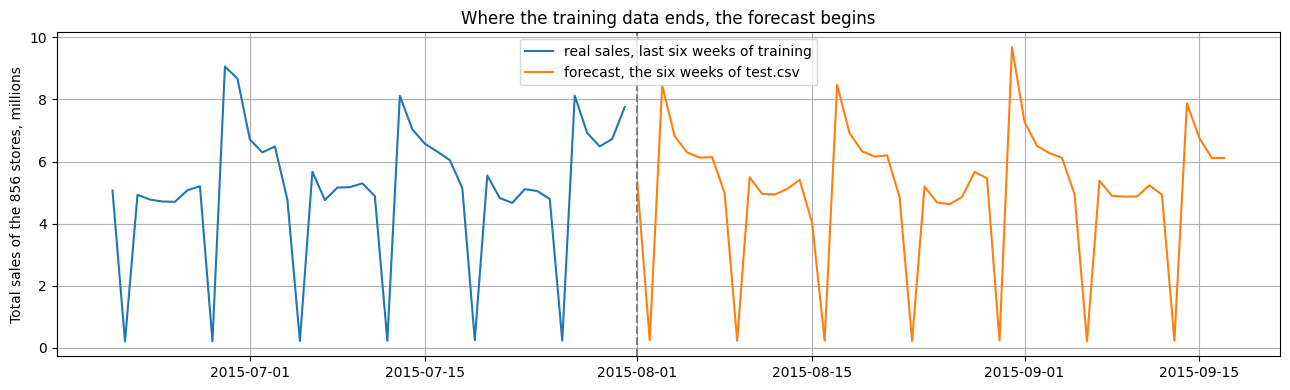

In [8]:
daily_recent = recent.group_by("Date").agg(pl.col("Sales").sum().alias("total")).sort("Date")
daily_forecast = (open_forecast.group_by("Date").agg(pl.col("prediction").sum().alias("total"))
                  .sort("Date"))
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_recent["Date"], daily_recent["total"] / 1e6, label="real sales, last six weeks of training")
ax.plot(daily_forecast["Date"], daily_forecast["total"] / 1e6, label="forecast, the six weeks of test.csv")
ax.axvline(date(2015, 8, 1), color="gray", linestyle="--")
ax.set_ylabel("Total sales of the 856 stores, millions")
ax.set_title("Where the training data ends, the forecast begins")
ax.legend()
plt.tight_layout()
plt.show()

The forecast looks like sales. Every closed row is zero, 5,984 of
them. The weekday shape of the last six weeks is kept: Monday and the few
open Sundays highest, Saturday lowest, the other days within a few percent.
And for a typical store the forecast level is the recent level - the median
ratio is 1.002, and ninety percent of the stores sit between 0.94 and 1.07.

The chart continues the story across the line: the same weekly rhythm, and
the same two-week promotion cycle that lifts every second Monday. A forecast
that broke the rhythm at the line would be the first thing to distrust.

## One new row

The last thing the file must do is score a row that arrives on its own: one
store, one day. The example is store 1 on Thursday 20 August 2015, a
promotion day.

There is a trap here, and it is worth showing rather than telling. The
closed-day columns ask whether the shop is open tomorrow and how many closed
days sit in the next seven. To answer, the model needs the opening plan
around the day. A row that arrives alone has no neighbours, so every one of
those columns gets the value "unknown" - a value the model met only at the
two edges of its training calendar, and never on a normal day. What it
predicts from there is anyone's guess.

So `predict` takes the plan as a second argument, and it refuses a row that
comes without it: a day after the training period whose day before is
neither in the training calendar nor in the plan raises an error that says
what to pass. The wrong number below is produced with that guard switched
off, on purpose, because seeing it is the best argument for the guard.

In [9]:
one = test.filter((pl.col("Store") == 1) & (pl.col("Date") == date(2015, 8, 20)))
plan = test.filter(pl.col("Store") == 1)          # the opening plan of store 1
model = Forecaster.load(MODELS / "forecaster.pkl")

try:
    model.predict(one)
except ValueError as error:
    print("With the guard on:", str(error)[:80], "...")
alone = model.predict(one, strict=False)["prediction"][0]
with_plan = model.predict(one, planned=plan)["prediction"][0]
same_day = forecast.filter((pl.col("Store") == 1) & (pl.col("Date") == date(2015, 8, 20)))["prediction"][0]
print(one.select(["Store", "Date", "DayOfWeek", "Open", "Promo"]))
print(f"\nThe row alone, guard off:           {alone:,.0f}")
print(f"The row with the opening plan:      {with_plan:,.0f}")
print(f"The same day in the full forecast:  {same_day:,.0f}")
print(f"\nThe last six Thursdays of store 1 in the training data, promotion days only:")
print(before.filter((pl.col("Store") == 1) & (pl.col("DayOfWeek") == 4) & (pl.col("Promo") == 1))
      .select(["Date", "Sales"]).tail(6))

With the guard on: 1 rows have no opening plan for the day before them, so their closed-day columns ...
shape: (1, 5)
┌───────┬────────────┬───────────┬──────┬───────┐
│ Store ┆ Date       ┆ DayOfWeek ┆ Open ┆ Promo │
│ ---   ┆ ---        ┆ ---       ┆ ---  ┆ ---   │
│ i64   ┆ date       ┆ i64       ┆ i64  ┆ i64   │
╞═══════╪════════════╪═══════════╪══════╪═══════╡
│ 1     ┆ 2015-08-20 ┆ 4         ┆ 1    ┆ 1     │
└───────┴────────────┴───────────┴──────┴───────┘

The row alone, guard off:           5,395
The row with the opening plan:      4,496
The same day in the full forecast:  4,496

The last six Thursdays of store 1 in the training data, promotion days only:
shape: (6, 2)
┌────────────┬───────┐
│ Date       ┆ Sales │
│ ---        ┆ ---   │
│ date       ┆ i64   │
╞════════════╪═══════╡
│ 2015-04-02 ┆ 6574  │
│ 2015-04-16 ┆ 4116  │
│ 2015-04-30 ┆ 6228  │
│ 2015-05-07 ┆ 4529  │
│ 2015-05-21 ┆ 3755  │
│ 2015-06-18 ┆ 4645  │
└────────────┴───────┘


The same two steps work from the command line, without a notebook:

```
python -m src.forecaster fit
python -m src.forecaster predict data/test.csv --out data/predictions_test.csv
```

The first command trains on every open day in `data/` and writes
`models/forecaster.pkl` with its model card. The second reads any file in
the shape of `test.csv` and writes it back with a `prediction` column. A
file with the rows of a whole period is its own opening plan; a file with a
single row should carry the days around it too.

## After the forecast: what a company adds

This repository stops where the forecast is written. In a company the same
model would live inside a loop, and the loop is the part that is usually
called MLOps. Four pieces, none of them needed here:

- **Monitoring.** When the real sales of August arrive, the forecast is
  scored against them, and the error is compared with the 0.12 the backtest
  promised. `python -m src.forecaster evaluate` is the scoring half of this:
  it joins the real sales to a prediction file and reports the error,
  overall and per week, and with `--threshold` it flags the weeks above a
  line. The backtest gives the line: its four windows scored between 0.10
  and 0.17, so one week above 0.17 is a warning and two in a row are an
  alarm. The loop that runs this every week is not here.
- **Scheduled retraining, with a challenger.** Every week the newest rows
  are added and the model is trained again, because the newest days are the
  most valuable. `python -m src.forecaster fit` is that step. The new model
  is not promoted because it is newer: it is scored on the last window next
  to the model in production, and it replaces it only if it is not worse by
  more than the seed noise. Champion and challenger, in the usual words.
- **A model registry.** Every trained file is kept with its card - the
  training period, the code version, the packages, the validation score -
  so that a forecast made in March can be traced to the model that made it.
  The JSON file next to `forecaster.pkl` is the small version of that.
- **Serving.** An interface that other systems call to get a prediction.
  Here it is a Python class and a command line.
- **Continuous integration.** Every change to the code is checked by a
  fresh machine that installs the packages and runs the tests, so that
  "it works on my computer" stops being an argument. This repository has
  it: `tests/` and a GitHub workflow. Its first run failed, because the
  tests had been started locally with `python -m pytest` and the workflow
  ran plain `pytest`, which could not find `src`. The code was fine; the
  two commands were not the same. That difference is the kind of thing
  continuous integration exists to catch, and `pytest.ini` now makes the
  plain command work everywhere.

What is here already is the part that matters most for the numbers: the
fitted pieces travel together in one file, the training and the scoring use
the same code, and the file says what it was trained on.

## Key findings

1. **The saved model reproduces the notebooks.** Trained before the last
   window, saved, loaded and asked to predict it: 0.1083 against the 0.1102
   of notebook 06. The production path is the experiment path.
2. **The model has learned, not memorised.** Training days 0.0895, hidden
   days 0.1083, baseline 0.1449. The tree count, chosen inside every fit,
   is the guard.
3. **A leak shown, not only claimed.** With the number of customers the
   hidden window scores 0.0620. Every real feature has a named source that
   is known six weeks ahead.
4. **The forecast holds its shape.** 41,088 rows for 856 stores; closed
   days at zero, weekday means within a few percent of the last six weeks,
   store levels at a median of 1.002 times their recent past.
5. **A single row needs its neighbours.** Store 1 on 20 August: 5,395 when
   the row arrives alone, 4,496 with the opening plan around it. The
   closed-day columns are the best features of the model and they need the
   calendar to work. `predict` takes the plan as a second argument, and
   refuses a row that comes without it.

The project is complete. Nine notebooks, one recipe, one file that holds it,
and a forecast for the six weeks the competition asked for.